# Sales Data Analysis with Python and SQL

A reproducible analysis workflow that loads spreadsheet data into pandas and SQLite, uses SQL to aggregate monthly product sales, exports analysis tables and visualises trends.

**Environment note:** This notebook was originally developed in Google Colab. Upload and download cells may require Colab, while the analysis logic is standard Python/SQL.


In [ ]:
# Step 1: Upload Excel file
from google.colab import files
import pandas as pd

print("Please upload your Excel file:")
uploaded = files.upload()

# Extract filename
filename = list(uploaded.keys())[0]

# Load Excel into DataFrame
df = pd.read_excel(filename)

print("File uploaded successfully.")
print("Preview of data:")
df.head()

In [ ]:
# Step 2: Start SQL environment in Colab

# Install SQL extension if not already installed
!pip install ipython-sql

# Load SQL magic
%load_ext sql

# Create an in-memory SQLite database
%sql sqlite://

# Register the DataFrame as a SQL table
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql("my_table", conn, if_exists="replace", index=False)

print("SQL environment initialized. Table name: my_table")

# Example query pattern
query = """
SELECT *
FROM my_table
LIMIT 10
"""
pd.read_sql_query(query, conn)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.9 MB/s eta 0:00:00
SQL environment initialized. Table name: my_table


,date,product_id,product_name,units_sold,price_per_unit,cost_per_unit,promo_flag
0,2023-01-02,P1,PremiumJuice,507,24,9.5,0
1,2023-01-02,P2,SparklingWater,1278,12,4.4,1
2,2023-01-02,P3,EnergyDrink,486,30,11.0,1
3,2023-01-02,P4,VitaminWater,408,28,11.3,0
4,2023-01-09,P1,PremiumJuice,497,24,9.5,0
5,2023-01-09,P2,SparklingWater,1021,12,4.4,0
6,2023-01-09,P3,EnergyDrink,353,30,11.0,0
7,2023-01-09,P4,VitaminWater,485,28,11.3,0
8,2023-01-16,P1,PremiumJuice,484,24,9.5,0
9,2023-01-16,P2,SparklingWater,954,12,4.4,0


In [ ]:
#sum by product type
query = """
select product_name, count(*) as count
from my_table
group by product_name
"""
result=pd.read_sql_query(query,conn)
result

,product_name,count
0,EnergyDrink,104
1,PremiumJuice,104
2,SparklingWater,104
3,VitaminWater,104


In [ ]:
#total number of units sold by product_name
query= """
select product_name, sum(units_sold) as Units
from my_table
where date like '%2024%'
group by product_name
"""
result=pd.read_sql_query(query,conn)
result

,product_name,Units
0,EnergyDrink,17206
1,PremiumJuice,25634
2,SparklingWater,51030
3,VitaminWater,22022


In [ ]:
query = """
SELECT
    strftime('%Y-%m', date) as sale_month,
    product_name,
    SUM(units_sold) as total_units_sold
FROM
    my_table
WHERE
    strftime('%Y', date) = '2024'
GROUP BY
    sale_month, product_name
ORDER BY
    sale_month, product_name
"""

result = pd.read_sql_query(query, conn)
result

,sale_month,product_name,total_units_sold
0,2024-01,EnergyDrink,1896
1,2024-01,PremiumJuice,2565
2,2024-01,SparklingWater,4849
3,2024-01,VitaminWater,2149
4,2024-02,EnergyDrink,1387
5,2024-02,PremiumJuice,2053
6,2024-02,SparklingWater,3911
7,2024-02,VitaminWater,1724
8,2024-03,EnergyDrink,1422
9,2024-03,PremiumJuice,1905


In [ ]:
query = """
SELECT
    strftime('%Y-%m', date) as sale_month,
    product_name,
    SUM(units_sold) as total_units_sold
FROM
    my_table
WHERE
    strftime('%Y', date) = '2024'
GROUP BY
    sale_month, product_name
ORDER BY
    sale_month, product_name
"""

result = pd.read_sql_query(query, conn)
result

,sale_month,product_name,total_units_sold
0,2024-01,EnergyDrink,1896
1,2024-01,PremiumJuice,2565
2,2024-01,SparklingWater,4849
3,2024-01,VitaminWater,2149
4,2024-02,EnergyDrink,1387
5,2024-02,PremiumJuice,2053
6,2024-02,SparklingWater,3911
7,2024-02,VitaminWater,1724
8,2024-03,EnergyDrink,1422
9,2024-03,PremiumJuice,1905


In [ ]:
from google.colab import files

# Save the result DataFrame to an Excel file
output_filename = '2024_monthly_product_sales.xlsx'
result.to_excel(output_filename, index=False)

# Provide a link to download the file
files.download(output_filename)

print(f"Results saved to {output_filename} and ready for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results saved to 2024_monthly_product_sales.xlsx and ready for download.


In [ ]:
result.to_sql("monthly_sales_2024", conn, if_exists="replace", index=False)
print("DataFrame 'result' registered as SQL table 'monthly_sales_2024'.")

DataFrame 'result' registered as SQL table 'monthly_sales_2024'.


In [ ]:
query_energy_drink = """
SELECT sale_month, total_units_sold
FROM monthly_sales_2024
WHERE product_name = 'EnergyDrink'
ORDER BY total_units_sold DESC
LIMIT 1
"""
max_sales_energy_drink = pd.read_sql_query(query_energy_drink, conn)
print("Max Sales for EnergyDrink (2024):")
print(max_sales_energy_drink)

Max Sales for EnergyDrink (2024):
  sale_month  total_units_sold
0    2024-01              1896


In [ ]:
query_premium_juice = """
SELECT sale_month, total_units_sold
FROM monthly_sales_2024
WHERE product_name = 'PremiumJuice'
ORDER BY total_units_sold DESC
LIMIT 1
"""
max_sales_premium_juice = pd.read_sql_query(query_premium_juice, conn)
print("Max Sales for PremiumJuice (2024):")
print(max_sales_premium_juice)

Max Sales for PremiumJuice (2024):
  sale_month  total_units_sold
0    2024-01              2565


In [ ]:
query_sparkling_water = """
SELECT sale_month, total_units_sold
FROM monthly_sales_2024
WHERE product_name = 'SparklingWater'
ORDER BY total_units_sold DESC
LIMIT 1
"""
max_sales_sparkling_water = pd.read_sql_query(query_sparkling_water, conn)
print("Max Sales for SparklingWater (2024):")
print(max_sales_sparkling_water)

Max Sales for SparklingWater (2024):
  sale_month  total_units_sold
0    2024-09              5261


In [ ]:
query_vitamin_water = """
SELECT sale_month, total_units_sold
FROM monthly_sales_2024
WHERE product_name = 'VitaminWater'
ORDER BY total_units_sold DESC
LIMIT 1
"""
max_sales_vitamin_water = pd.read_sql_query(query_vitamin_water, conn)
print("Max Sales for VitaminWater (2024):")
print(max_sales_vitamin_water)

Max Sales for VitaminWater (2024):
  sale_month  total_units_sold
0    2024-09              2170


In [ ]:
energy_drink_sales = result[result['product_name'] == 'EnergyDrink'][['sale_month', 'total_units_sold']]

output_filename_energy_drink = 'EnergyDrink_monthly_sales.xlsx'
energy_drink_sales.to_excel(output_filename_energy_drink, index=False)

print(f"'EnergyDrink' monthly sales data saved to {output_filename_energy_drink}")

'EnergyDrink' monthly sales data saved to EnergyDrink_monthly_sales.xlsx


In [ ]:
premium_juice_sales = result[result['product_name'] == 'PremiumJuice'][['sale_month', 'total_units_sold']]

output_filename_premium_juice = 'PremiumJuice_monthly_sales.xlsx'
premium_juice_sales.to_excel(output_filename_premium_juice, index=False)

print(f"'PremiumJuice' monthly sales data saved to {output_filename_premium_juice}")

'PremiumJuice' monthly sales data saved to PremiumJuice_monthly_sales.xlsx


In [ ]:
sparkling_water_sales = result[result['product_name'] == 'SparklingWater'][['sale_month', 'total_units_sold']]

output_filename_sparkling_water = 'SparklingWater_monthly_sales.xlsx'
sparkling_water_sales.to_excel(output_filename_sparkling_water, index=False)

print(f"'SparklingWater' monthly sales data saved to {output_filename_sparkling_water}")

'SparklingWater' monthly sales data saved to SparklingWater_monthly_sales.xlsx


In [ ]:
vitamin_water_sales = result[result['product_name'] == 'VitaminWater'][['sale_month', 'total_units_sold']]

output_filename_vitamin_water = 'VitaminWater_monthly_sales.xlsx'
vitamin_water_sales.to_excel(output_filename_vitamin_water, index=False)

print(f"'VitaminWater' monthly sales data saved to {output_filename_vitamin_water}")

'VitaminWater' monthly sales data saved to VitaminWater_monthly_sales.xlsx


In [ ]:
from google.colab import files

output_filename_energy_drink = 'EnergyDrink_monthly_sales.xlsx'
files.download(output_filename_energy_drink)

output_filename_premium_juice = 'PremiumJuice_monthly_sales.xlsx'
files.download(output_filename_premium_juice)

output_filename_sparkling_water = 'SparklingWater_monthly_sales.xlsx'
files.download(output_filename_sparkling_water)

output_filename_vitamin_water = 'VitaminWater_monthly_sales.xlsx'
files.download(output_filename_vitamin_water)

print("All four monthly sales Excel files are ready for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All four monthly sales Excel files are ready for download.


In [ ]:
vitamin_water_sales = result[result['product_name'] == 'VitaminWater'][['sale_month', 'total_units_sold']]

output_filename_vitamin_water = 'VitaminWater_monthly_sales.xlsx'
vitamin_water_sales.to_excel(output_filename_vitamin_water, index=False)

print(f"'VitaminWater' monthly sales data saved to {output_filename_vitamin_water}")

'VitaminWater' monthly sales data saved to VitaminWater_monthly_sales.xlsx


In [ ]:
query_all_years = """
SELECT
    strftime('%Y-%m', date) as sale_month,
    product_name,
    SUM(units_sold) as total_units_sold
FROM
    my_table
GROUP BY
    sale_month, product_name
ORDER BY
    sale_month, product_name
"""

all_years_monthly_sales = pd.read_sql_query(query_all_years, conn)
print("Monthly sales data for all years and products:")
all_years_monthly_sales.head()

Monthly sales data for all years and products:


,sale_month,product_name,total_units_sold
0,2023-01,EnergyDrink,1924
1,2023-01,PremiumJuice,2404
2,2023-01,SparklingWater,5154
3,2023-01,VitaminWater,2139
4,2023-02,EnergyDrink,1548


In [ ]:
all_years_monthly_sales['sale_month'] = pd.to_datetime(all_years_monthly_sales['sale_month'])
print("Converted 'sale_month' column to datetime type.")
all_years_monthly_sales.info()

Converted 'sale_month' column to datetime type.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sale_month        96 non-null     datetime64[ns]
 1   product_name      96 non-null     object        
 2   total_units_sold  96 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.4+ KB


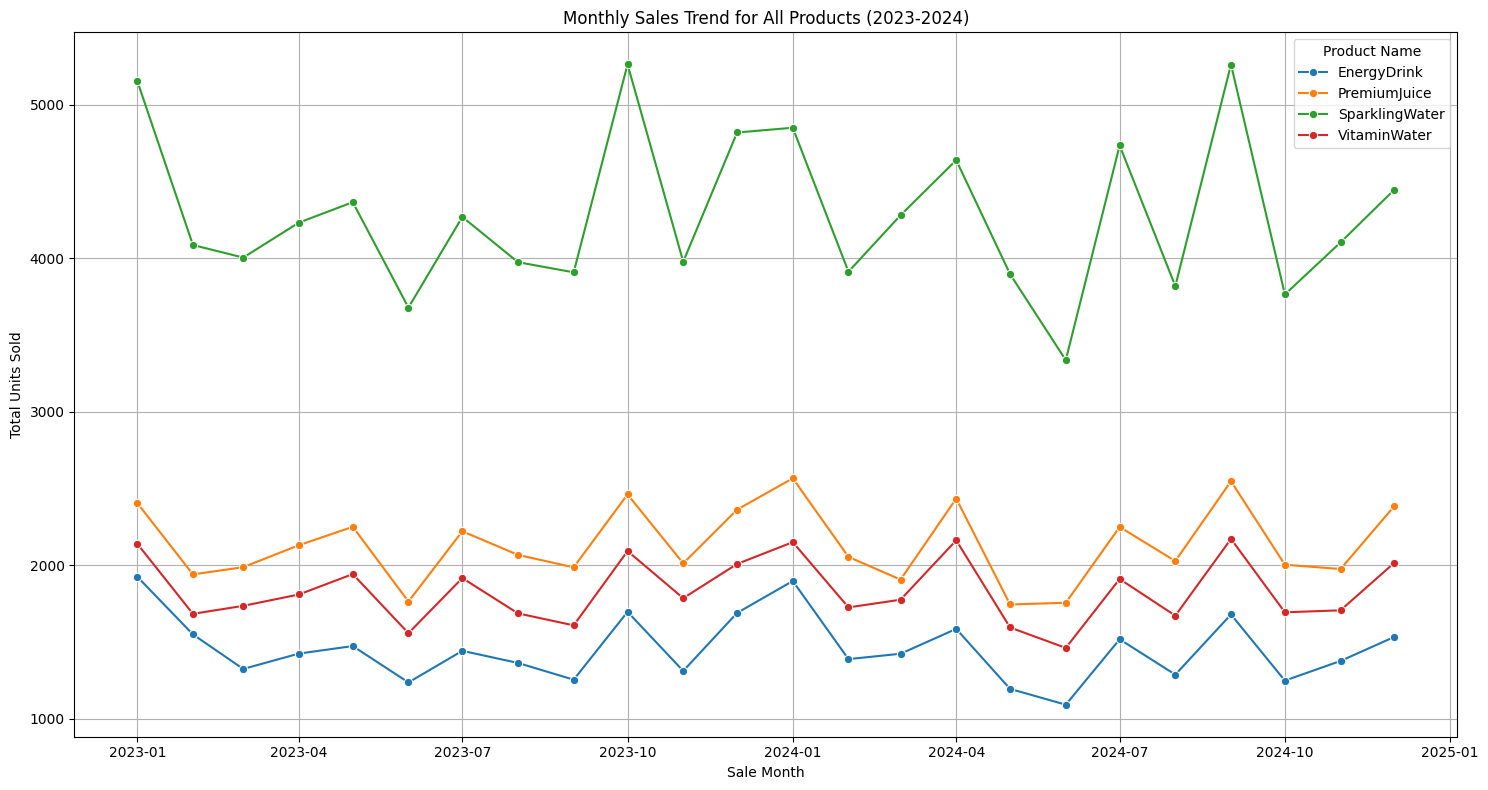

Time series plot showing monthly sales trends for all products has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.lineplot(data=all_years_monthly_sales, x='sale_month', y='total_units_sold', hue='product_name', marker='o')
plt.title('Monthly Sales Trend for All Products (2023-2024)')
plt.xlabel('Sale Month')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.legend(title='Product Name')
plt.tight_layout()
plt.show()

print("Time series plot showing monthly sales trends for all products has been generated.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Re-create and save the combined plot
plt.figure(figsize=(15, 8))
sns.lineplot(data=all_years_monthly_sales, x='sale_month', y='total_units_sold', hue='product_name', marker='o')
plt.title('Monthly Sales Trend for All Products (2023-2024)')
plt.xlabel('Sale Month')
plt.ylabel('Total Units Sold')
plt.grid(True)
plt.legend(title='Product Name')
plt.tight_layout()
combined_plot_filename = 'monthly_sales_trend_all_products.png'
plt.savefig(combined_plot_filename)
plt.close() # Close the plot to free memory and prevent re-display in output
files.download(combined_plot_filename)
print(f"Downloaded: {combined_plot_filename}")

# 2. Re-create and save individual product plots
unique_products = all_years_monthly_sales['product_name'].unique()

for product in unique_products:
    product_data = all_years_monthly_sales[all_years_monthly_sales['product_name'] == product]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=product_data, x='sale_month', y='total_units_sold', marker='o')
    plt.title(f'Monthly Sales Trend for {product} (2023-2024)')
    plt.xlabel('Sale Month')
    plt.ylabel('Total Units Sold')
    plt.grid(True)
    plt.tight_layout()
    individual_plot_filename = f'{product.replace(" ", "")}_monthly_sales_trend.png'
    plt.savefig(individual_plot_filename)
    plt.close() # Close the plot to free memory and prevent re-display in output
    files.download(individual_plot_filename)
    print(f"Downloaded: {individual_plot_filename}")

print("All generated plots are ready for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: monthly_sales_trend_all_products.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: SparklingWater_monthly_sales_trend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: VitaminWater_monthly_sales_trend.png
All generated plots are ready for download.


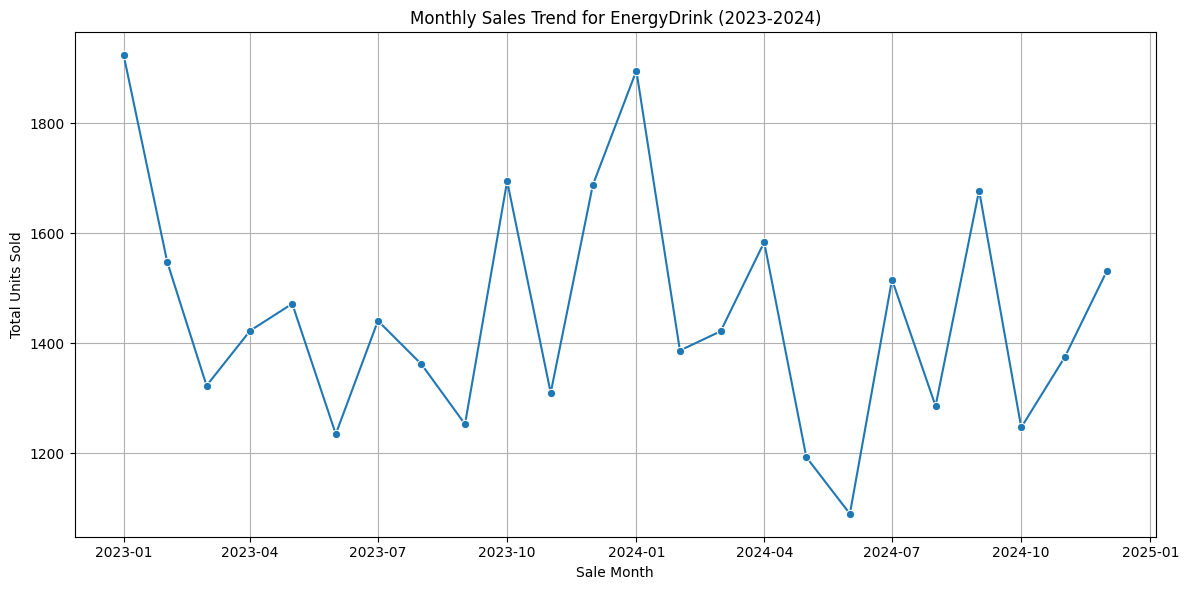

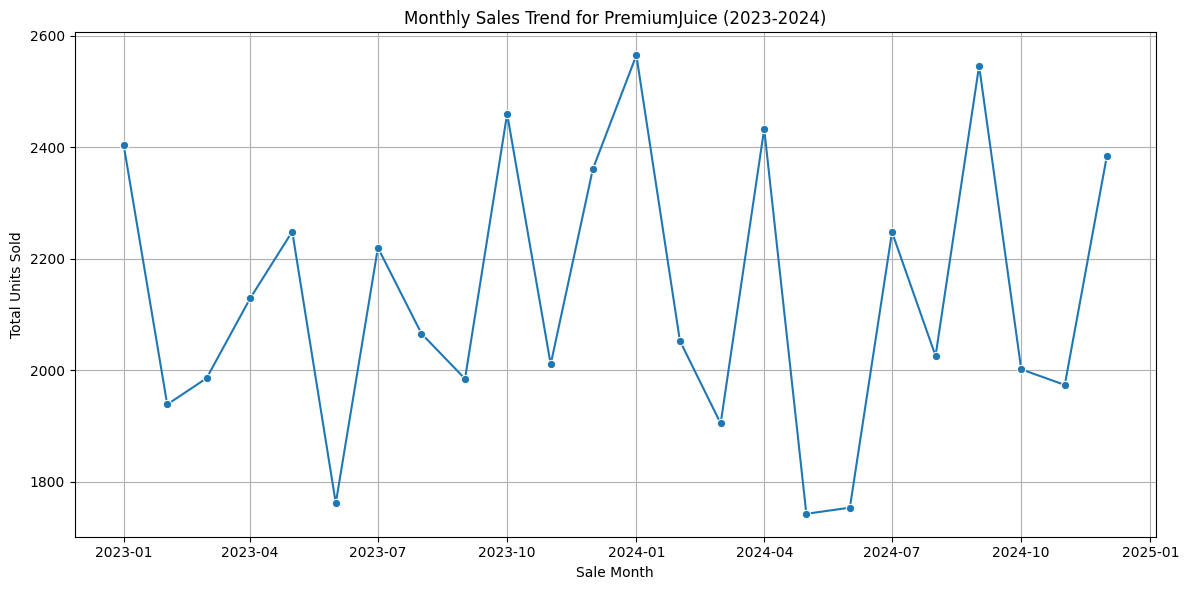

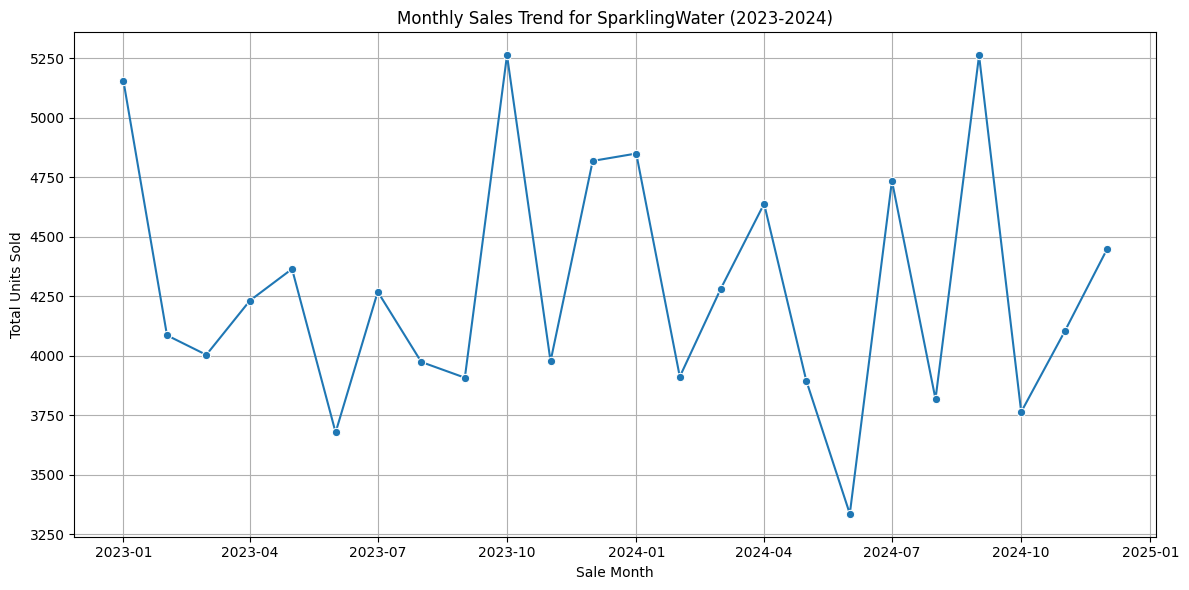

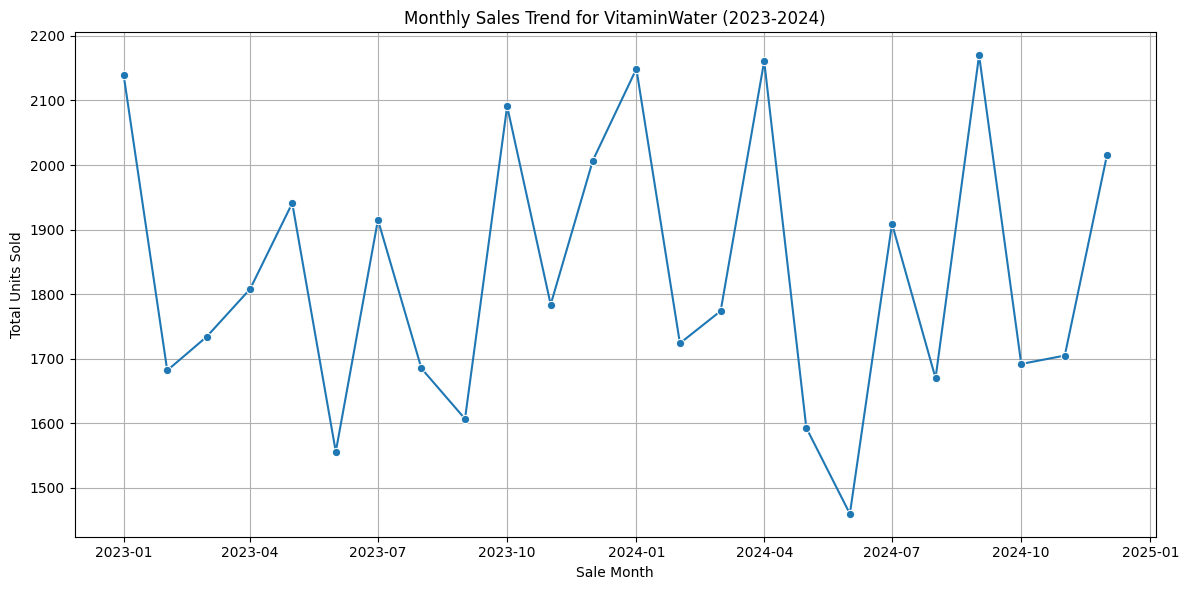

Individual monthly sales trend plots for each product have been generated.


In [ ]:
unique_products = all_years_monthly_sales['product_name'].unique()

for product in unique_products:
    product_data = all_years_monthly_sales[all_years_monthly_sales['product_name'] == product]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=product_data, x='sale_month', y='total_units_sold', marker='o')
    plt.title(f'Monthly Sales Trend for {product} (2023-2024)')
    plt.xlabel('Sale Month')
    plt.ylabel('Total Units Sold')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Individual monthly sales trend plots for each product have been generated.")